In [7]:
import jax
import jax.numpy as jnp
import jax.scipy.stats as stats
import numpy as np

from functools import partial
import matplotlib.pyplot as plt

import blackjax

# Set device to CPU 
jax.config.update("jax_platform_name", "cpu")


In [8]:

observed = 4.
def logdensity_fn(z):
    mean = z**2
    logpdf = stats.norm.logpdf(observed, mean, 0.5) + stats.norm.logpdf(z, 0, 1)
    return jnp.sum(logpdf)


In [9]:
from probjax.inference.kernels.independent_mh import GaussianIMHKernel

kernel = GaussianIMHKernel(logdensity_fn, 0., 2.)

In [10]:
state = kernel.init_state(jnp.ones((1,)))

In [11]:
kernel.params

GaussianParams(mean=Array([0.], dtype=float32, weak_type=True), cov=None, scale=Array([2.], dtype=float32, weak_type=True))

In [6]:
kernel(jax.random.PRNGKey(5), state)

(RWState(position=Array([-1.433723], dtype=float32), logdensity=Array(-9.734193, dtype=float32)),
 RWInfo(acceptance_rate=Array(1., dtype=float32), is_accepted=Array(True, dtype=bool), proposal=RWState(position=Array([-1.433723], dtype=float32), logdensity=Array(-9.734193, dtype=float32))))

In [ ]:
def logdensity_fn(z, y):
    mean = z**2
    logpdf = stats.norm.logpdf(observed, mean, 0.5) + stats.norm.logpdf(z, 0, 1) + stats.norm.logpdf(y, 0, 1)
    return jnp.sum(logpdf)

In [6]:
inner_kernel1 = HMCKernel(logdensity_fn)
inner_kernel2 = GaussianMHKernel(logdensity_fn)

kernels = {"z": inner_kernel1, "y": inner_kernel2}
positions = {"z": jnp.ones((2,)), "y": jnp.ones((1,))}

kernel = GibbsKernel(logdensity_fn, kernels)

NameError: name 'HMCKernel' is not defined

In [6]:
state = kernel.init_state(positions)

In [7]:
state["y"].position

Array([1.], dtype=float32)

In [11]:
jax.jit(kernel)(jax.random.PRNGKey(0),state)

({'y': RWState(position=Array([1.], dtype=float32), logdensity=Array(-42.127335, dtype=float32)),
  'z': HMCState(position=Array([1.0902035, 1.0023978], dtype=float32), logdensity=Array(-39.97501, dtype=float32), logdensity_grad=Array([23.430273, 23.016647], dtype=float32))},
 {'y': RWInfo(acceptance_rate=Array(0.00053104, dtype=float32), is_accepted=Array(False, dtype=bool), proposal=RWState(position=Array([1.], dtype=float32), logdensity=Array(-42.127335, dtype=float32))),
  'z': HMCInfo(momentum=Array([-0.25122508, -1.119231  ], dtype=float32), acceptance_rate=Array(0.9998245, dtype=float32), is_accepted=Array(True, dtype=bool), is_divergent=Array(False, dtype=bool), energy=Array(42.785408, dtype=float32), proposal=IntegratorState(position=Array([1.0902035, 1.0023978], dtype=float32), momentum=Array([-2.0634341, -1.1674898], dtype=float32), logdensity=Array(-39.97501, dtype=float32), logdensity_grad=Array([23.430273, 23.016647], dtype=float32)), num_integration_steps=Array(10, dtype

In [4]:
hasattr(kernel.params, "step_size")

True

In [20]:
import numpy as np 
import math 



In [21]:
sampler = ARS(jax.vmap(logdensity_fn), jax.vmap(jax.grad(logdensity_fn)), xi=np.array([-4.,1,4]))

TypeError: Using a non-tuple sequence for multidimensional indexing is not allowed; use `arr[array(seq)]` instead of `arr[seq]`. See https://github.com/google/jax/issues/4564 for more information.

In [5]:
kernel.params._asdict()

{'step_size': Array(1.6829143, dtype=float32, weak_type=True),
 'scale': Array([1., 1.], dtype=float32)}

In [6]:
kernel(jax.random.PRNGKey(2), state)

(RWState(position=Array([2.3145185, 2.698021 ], dtype=float32), logdensity=Array(-33.798332, dtype=float32)),
 RWInfo(acceptance_rate=Array(1., dtype=float32), is_accepted=Array(True, dtype=bool), proposal=RWState(position=Array([2.3145185, 2.698021 ], dtype=float32), logdensity=Array(-33.798332, dtype=float32))))

In [8]:
kernel.adapt_params(jax.random.PRNGKey(2), state.position, method="step_size_and_scale")

(RWState(position=Array([2.2556024, 1.8837084], dtype=float32), logdensity=Array(-9.381837, dtype=float32)),
 AdaptationInfo(state=RWState(position=Array([[1.       , 1.       ],
        [1.       , 1.       ],
        [2.5691714, 1.7865127],
        [2.5691714, 1.7865127],
        [2.5691714, 1.7865127],
        [2.5691714, 1.7865127],
        [2.5691714, 1.7865127],
        [2.355719 , 1.9361055],
        [2.355719 , 1.9361055],
        [2.355719 , 1.9361055],
        [1.5174516, 1.8178756],
        [1.5174516, 1.8178756],
        [1.5174516, 1.8178756],
        [1.5174516, 1.8178756],
        [1.5174516, 1.8178756],
        [1.7015871, 1.7827551],
        [1.7015871, 1.7827551],
        [1.8040062, 1.7326418],
        [1.8040062, 1.7326418],
        [1.8040062, 1.7326418],
        [1.8040062, 1.7326418],
        [1.8040062, 1.7326418],
        [1.8040062, 1.7326418],
        [1.7023752, 1.8200752],
        [1.7023752, 1.8200752],
        [1.8620775, 1.8926849],
        [1.8620775, 1

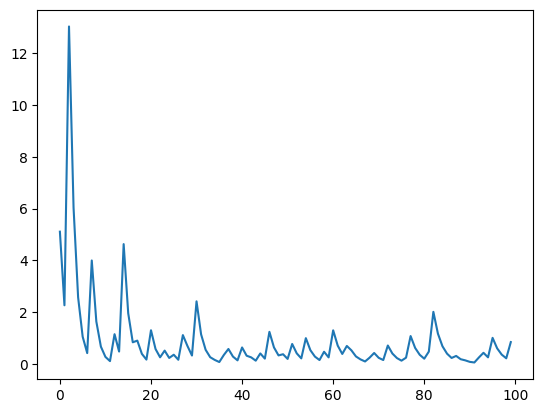

In [7]:
plt.plot(jnp.exp(kernel.adapt_params(jax.random.PRNGKey(2), state.position)[1].adaptation_state.log_step_size))

In [8]:
blackjax.rmh.build_kernel()

<function blackjax.mcmc.random_walk.build_rmh.<locals>.kernel(rng_key: jax.Array, state: blackjax.mcmc.random_walk.RWState, logdensity_fn: Callable, transition_generator: Callable, proposal_logdensity_fn: Optional[Callable] = None) -> tuple[blackjax.mcmc.random_walk.RWState, blackjax.mcmc.random_walk.RWInfo]>

In [67]:
def f(x,y):

    for i in range(5000):
        x += 0.001*x
    return x + y

In [82]:
from jax import make_jaxpr
from jax import numpy as jnp
from jax.core import eval_jaxpr
from jax.interpreters.partial_eval import partial_eval_jaxpr_nounits


def precompute(func, arg_list, known_argnums):
    jaxpr = make_jaxpr(func)(*arg_list)
    unknowns = [False if k in known_argnums else True for k in range(len(arg_list))]
    instantiate = False

    (known_jaxpr, unknown_jaxpr, _, _) = partial_eval_jaxpr_nounits(jaxpr, unknowns, instantiate)

    known_values = [arg_k for (k, arg_k) in enumerate(arg_list) if k in known_argnums]
    precomputed_values = eval_jaxpr(known_jaxpr.jaxpr, known_jaxpr.consts, *known_values)


    def inner(*args):
        values = eval_jaxpr(unknown_jaxpr.jaxpr, unknown_jaxpr.consts, *precomputed_values, *args, propagate_source_info=False)
        return values if len(values) > 1 else values[0]
    return inner

In [88]:
f(2,1)

297.08567232528173

In [83]:
g_f = precompute(f, [jnp.ones((1000,)), 1], [0])

In [86]:
jax.make_jaxpr(g_f)(1.)

{ lambda a:f32[1000]; b:f32[]. let
    c:f32[] = convert_element_type[new_dtype=float32 weak_type=False] b
    d:f32[1000] = add a c
  in (d,) }

In [90]:
%%timeit 
jax.jit(f)(jnp.ones((1000,)),1)

442 µs ± 25.6 µs per loop (mean ± std. dev. of 7 runs, 1,000 loops each)


In [91]:
%%timeit
jax.jit(g_f)(1)

36 µs ± 952 ns per loop (mean ± std. dev. of 7 runs, 10,000 loops each)


In [4]:

state, info = kernel.adapt_params(jax.random.PRNGKey(0), state.position, 1000, method="pathfinder")

In [5]:
kernel.params

HMCParams(step_size=Array(1.1663282, dtype=float32, weak_type=True), inverse_mass_matrix=Array([[ 1.6063698e-02, -5.7701300e-07],
       [-5.7701300e-07,  1.6063698e-02]], dtype=float32))

In [11]:
kernel.params

HMCParams(step_size=Array(0.75114405, dtype=float32, weak_type=True), inverse_mass_matrix=Array([0.01330452, 0.01622639], dtype=float32))

In [20]:
first_half = info.state.position[:200]
second_half = info.state.position[-200:]

In [23]:
blackjax.ess(first_half[None,...])

Array([123.13278, 247.67601], dtype=float32)

In [24]:
blackjax.ess(second_half[None,...])

Array([138.66486, 156.12479], dtype=float32)

In [16]:
kernel(jax.random.PRNGKey(50), state)

(HMCState(position=Array([1.8274282, 1.8035984], dtype=float32), logdensity=Array(-7.5743427, dtype=float32), logdensity_grad=Array([7.828791, 8.97518 ], dtype=float32)),
 HMCInfo(momentum=Array([ 0.32551032, -5.0030694 ], dtype=float32), acceptance_rate=Array(1., dtype=float32), is_accepted=Array(True, dtype=bool), is_divergent=Array(False, dtype=bool), energy=Array(8.623685, dtype=float32), proposal=IntegratorState(position=Array([1.8274282, 1.8035984], dtype=float32), momentum=Array([11.714154, -2.38544 ], dtype=float32), logdensity=Array(-7.5743427, dtype=float32), logdensity_grad=Array([7.828791, 8.97518 ], dtype=float32)), num_integration_steps=10))

In [1]:

from chex import PRNGKey
from jaxtyping import Array, PyTree 
from typing import Any, Callable, NamedTuple, Optional
from jax.tree_util import register_pytree_node_class



@register_pytree_node_class
class MCMCState:
    """MCMC state object."""

    def __init__(
        self, key: PRNGKey, state: PyTree[NamedTuple], params: Optional[PyTree[dict]] = None
    ) -> None:
        self.key = key
        self.state = state
        self.params = params

    def __repr__(self) -> str:
        return f"MCMCState(key={self.key}, state={self.state}, params={self.params})"
    
    def tree_flatten(self):
        flat_state, state_tree_def = jax.tree_util.tree_flatten(self.state)
        flat_params, params_tree_def = jax.tree_util.tree_flatten(self.params)
    
        return [self.key,] + flat_state + flat_params, (state_tree_def, params_tree_def)

    @classmethod
    def tree_unflatten(cls, aux_data, children):
        key, *state_children = children
        state_tree_def, params_tree_def = aux_data
        state = jax.tree_util.tree_unflatten(state_tree_def, state_children[:state_tree_def.num_leaves])
        params = jax.tree_util.tree_unflatten(params_tree_def, state_children[state_tree_def.num_leaves:state_tree_def.num_leaves + params_tree_def.num_leaves])
        return cls(key, state, params)
    

class MCMCKernel:
    
    def init_state(self, key: PRNGKey, x: PyTree[Array]) -> MCMCState:
        raise NotImplementedError("init_state method must be implemented")
    
    def __call__(self, state: MCMCState) -> MCMCState:
        raise NotImplementedError("__call__ method must be implemented")
    
class HMCKernel(MCMCKernel):
    
    def __init__(self, logdensity_fn: Callable, step_size:float = 1e-2,num_integration_steps:int = 10, inverse_mass_matrix: Optional[Array] = None) -> None:
        self.logdensity_fn = logdensity_fn
        self.step_size = step_size
        self.num_integration_steps = num_integration_steps
        self.inverse_mass_matrix = inverse_mass_matrix
        self.init_fn = blackjax.hmc.init
        self.update_fn = blackjax.hmc.build_kernel()
        
    
    def init_state(self, key: PRNGKey, x: PyTree[Array]) -> MCMCState:
        inverse_mass_matrix = jnp.atleast_1d(jax.tree_util.tree_map(jnp.ones_like, x))
        params = {"step_size": self.step_size, "inverse_mass_matrix": inverse_mass_matrix}
        state = self.init_fn(x, self.logdensity_fn)
        return MCMCState(key, state, params)
    
    def __call__(self, state: MCMCState) -> MCMCState:
        key_new, key = jax.random.split(state.key)
        new_state, info = self.update_fn(key, state.state, self.logdensity_fn, num_integration_steps=self.num_integration_steps, **state.params)
        return MCMCState(key_new, new_state, state.params), info
    
    
    
class MCMC:
    
    _print_every: int = 10
    _print_length: int = 30
    
    def __init__(
        self,
        kernel,
        verbose: bool = False,
    ) -> None:
        self.kernel = kernel
        self.verbose = verbose
        self._acceptance_rate = 0.0

    @partial(jax.jit, static_argnums=(0,))
    def run(self, state: MCMCState, num_steps: int):

        def body_fn(i, old_state):
            new_state, info = self.kernel(old_state)
            
            if self.verbose:
                jax.lax.cond(
                    i % self._print_every == 0,
                    lambda: jax.debug.callback(self._print_progress,i, num_steps, info),
                    lambda: None,
                )
            
            return new_state

        out_state = jax.lax.fori_loop(0, num_steps, body_fn, state)
        return out_state
    
    def _print_progress(self, iteration, total, info):

        percent = 100 * (iteration / float(total) + self._print_every / total)
        percent = min(percent, 100)

        percent = ("{0:." + str(2) + "f}").format(percent)

            
        filled_length = int(self._print_length * iteration // total+1)
        bar = '█' * filled_length + '-' * (self._print_length - filled_length)

        progress_bar = f'\rProgress: |{bar}| {percent}%'
        
        if info is not None:
            if hasattr(info, "acceptance_rate"):
                self._acceptance_rate = 0.8*self._acceptance_rate + 0.2*info.acceptance_rate
                progress_bar += f" | accept_prob: {self._acceptance_rate:.2f} |"
        
        print(progress_bar, end = "\r")

        if iteration == total: 
            print()
    
    


NameError: name 'partial' is not defined

In [193]:
kernel = HMCKernel(logdensity_fn, step_size=0.05)
mcmc = MCMC(kernel, verbose=True)

In [194]:
#state = jax.vmap(kernel.init_state)(jax.random.split(jax.random.key(0),10), jnp.ones((10,)))

In [195]:
state = kernel.init_state(jax.random.key(0), jax.random.normal(jax.random.key(0), (1000,)))

In [196]:
state = mcmc.run(state, 10000)

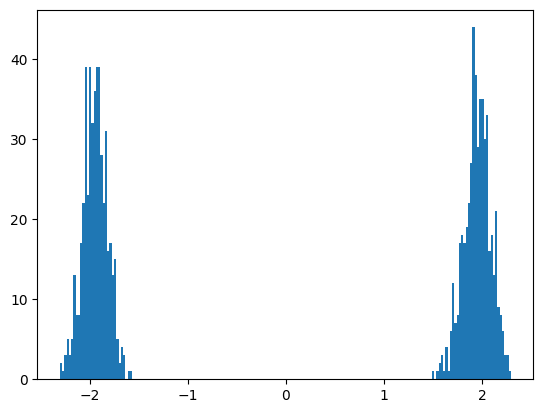

In [197]:
_ = plt.hist(state.state.position, bins=200)

In [ ]:
states = jax.vmap(kernel.init_state, in_axes=(None, 0))(jax.random.PRNGKey(0), jnp.ones((1000,)))

In [39]:
kernel = HMCKernel(logdensity_fn)
x = jnp.ones((10,))

In [126]:
state = kernel(state)

In [127]:
state = blackjax.rmh.init(x, logdensity_fn)

In [128]:
blackjax.rmh.build_kernel()(jax.random.PRNGKey(0), state, logdensity_fn, lambda k,x: x + jax.random.normal(k, x.shape))[1]

RWInfo(acceptance_rate=Array(1., dtype=float32), is_accepted=Array(True, dtype=bool), proposal=RWState(position=Array([-1.6105583 ,  1.0338528 ,  2.0863333 , -0.48029876,  1.4889567 ,
        2.062516  ,  1.5417483 ,  1.0170228 ,  1.2722685 ,  1.3052244 ],      dtype=float32), logdensity=Array(-123.20876, dtype=float32)))

In [14]:
def logdensity_fn(z):
    mean = z**2
    logpdf = stats.norm.logpdf(observed, mean, 0.5) + stats.norm.logpdf(z, 0, 1)
    return logpdf


In [15]:
blackjax.rmh(logdensity_fn,proposal_generator=lambda k, x: x + 0.1 * jax.random.normal(k, x.shape))

SamplingAlgorithm(init=<function rmh.__new__.<locals>.init_fn at 0x7f41f46ab5b0>, step=<function rmh.__new__.<locals>.step_fn at 0x7f41f46ab640>)

In [186]:
kernel = blackjax.additive_step_random_walk.build_kernel()

In [189]:
state = blackjax.additive_step_random_walk.init(jnp.ones((10,)), logdensity_fn)

In [192]:
kernel(jax.random.PRNGKey(0), state, logdensity_fn, lambda k: 0.1 * jax.random.normal(k, state.position.shape))

Unexpected exception formatting exception. Falling back to standard exception


Traceback (most recent call last):
  File "/root/miniconda3/envs/probjax/lib/python3.10/site-packages/IPython/core/interactiveshell.py", line 3550, in run_code
    exec(code_obj, self.user_global_ns, self.user_ns)
  File "/tmp/ipykernel_1605/1013864679.py", line 1, in <module>
    kernel(jax.random.PRNGKey(0), state, logdensity_fn, lambda k: 0.1 * jax.random.normal(k, state.position.shape))
  File "/root/miniconda3/envs/probjax/lib/python3.10/site-packages/blackjax/mcmc/random_walk.py", line 181, in kernel
  File "/root/miniconda3/envs/probjax/lib/python3.10/site-packages/blackjax/mcmc/random_walk.py", line 400, in kernel
    The current state of the chain.
  File "/root/miniconda3/envs/probjax/lib/python3.10/site-packages/blackjax/mcmc/random_walk.py", line 498, in generate
    return transition_energy
  File "/root/miniconda3/envs/probjax/lib/python3.10/site-packages/blackjax/mcmc/random_walk.py", line 493, in build_trajectory
    else:
  File "/root/miniconda3/envs/probjax/lib/pytho

In [182]:
algorithm.init(jax.random.PRNGKey(0), jnp.ones(10))

TypeError: additive_step_random_walk.__new__.<locals>.init_fn() takes 1 positional argument but 2 were given

In [100]:
blackjax.hmc.init(x, logdensity_fn)

HMCState(position=Array([1., 1., 1., 1., 1., 1., 1., 1., 1., 1.], dtype=float32), logdensity=Array(-196.4473, dtype=float32), logdensity_grad=Array([23., 23., 23., 23., 23., 23., 23., 23., 23., 23.], dtype=float32))

In [48]:
blackjax.hmc.build_kernel()(jax.random.key(0),blackjax.hmc.init(x, logdensity_fn), logdensity_fn, 1e-2,jnp.ones((1,)), 10)

(HMCState(position=Array(1.1300707, dtype=float32, weak_type=True), logdensity=Array(-16.612066, dtype=float32), logdensity_grad=Array(23.486849, dtype=float32, weak_type=True)),
 HMCInfo(momentum=Array(0.14389051, dtype=float32), acceptance_rate=Array(0.9998894, dtype=float32), is_accepted=Array(True, dtype=bool), is_divergent=Array(False, dtype=bool), energy=Array(19.655193, dtype=float32), proposal=Proposal(state=IntegratorState(position=Array(1.1300707, dtype=float32), momentum=Array(-2.4670331, dtype=float32), logdensity=Array(-16.612066, dtype=float32), logdensity_grad=Array(23.486849, dtype=float32)), energy=Array(19.655193, dtype=float32), weight=Array(-0.00011063, dtype=float32), sum_log_p_accept=Array(-0.00011063, dtype=float32)), num_integration_steps=10))

In [3]:

observed = 4.
def logdensity_fn(z):
    mean = z**2
    logpdf = stats.norm.logpdf(observed, mean, 0.5) + stats.norm.logpdf(z, 0, 1)
    return jnp.sum(logpdf)

# Build the kernel
step_size = 1e-2
inverse_mass_matrix = jnp.ones((1,))


nuts = blackjax.hmc(logdensity_fn, step_size, inverse_mass_matrix, num_integration_steps=10)

In [4]:


blackjax.hmc.init(0., lambda x: x)

HMCState(position=0.0, logdensity=0.0, logdensity_grad=Array(1., dtype=float32, weak_type=True))

In [ ]:
blackjax.irmh.init(0, lambda x: x)

RWState(position=0, logdensity=0)

In [7]:
out = mcmc(rng_key, state, 2000)

(array([0.20613711, 1.06933544, 1.36565731, 0.52822594, 0.06441785,
        0.        , 0.        , 0.        , 0.        , 0.        ,
        0.        , 0.        , 0.        , 0.        , 0.        ,
        0.        , 0.        , 0.        , 0.        , 0.        ,
        0.        , 0.        , 0.        , 0.        , 0.00644178,
        0.13527748, 0.80522247, 1.43007621, 0.75368765, 0.07730142]),
 array([-2.30802369, -2.15278721, -1.99755061, -1.842314  , -1.6870774 ,
        -1.53184092, -1.37660432, -1.22136772, -1.06613123, -0.91089463,
        -0.75565809, -0.60042149, -0.44518495, -0.28994837, -0.13471182,
         0.02052474,  0.1757613 ,  0.33099785,  0.48623443,  0.64147097,
         0.79670757,  0.95194411,  1.10718071,  1.2624172 ,  1.4176538 ,
         1.5728904 ,  1.72812688,  1.88336349,  2.03859997,  2.19383669,
         2.34907317]),
 <BarContainer object of 30 artists>)

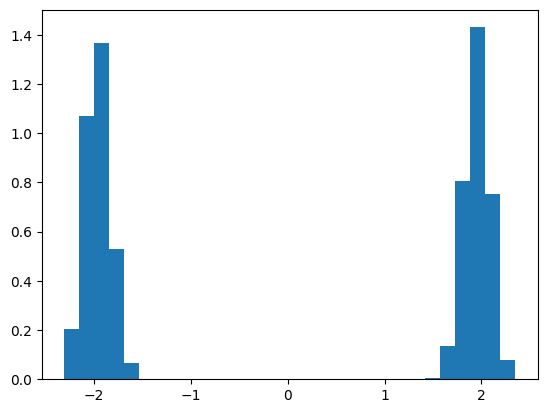

In [8]:
plt.hist(out[1][-1], bins=30, density=True)

In [9]:
@partial(jax.jit, static_argnums=(1,3))
def smc_inference_loop(rng_key, smc_kernel, initial_state, num_samples):
    """Run the temepered SMC algorithm.

    We run the adaptive algorithm until the tempering parameter lambda reaches the value
    lambda=1.

    """

    def one_step(carry, key):
        state, i = carry
        lmbda = i / num_samples
        next_state, _ = smc_kernel(key, state, lmbda)
        
        return (next_state, i +1), next_state.particles
    
    keys = jax.random.split(rng_key, num_samples)
    carry = (initial_state, 0)
    (final_state, _), samples = jax.lax.scan(one_step, carry, keys)
    return final_state, samples

In [10]:
from blackjax.smc import resampling

inv_mass_matrix = jnp.array([1.])

hmc_parameters = dict(
    step_size=1e-1, inverse_mass_matrix=inv_mass_matrix, num_integration_steps=10
)

prior_log_prob = lambda x: stats.norm.logpdf(x, 0, 1)
loglikelihood = lambda x: stats.norm.logpdf(observed, x**2, 0.5)

tempered = blackjax.tempered_smc(
    prior_log_prob,
    loglikelihood,
    blackjax.hmc.build_kernel(),
    blackjax.hmc.init,
    hmc_parameters,
    resampling.systematic,
    num_mcmc_steps=10,
)

rng_key, init_key, sample_key = jax.random.split(rng_key, 3)
initial_position = jax.random.normal(init_key, (1000,))
initial_smc_state = tempered.init(initial_position)

final_state, smc_samples = smc_inference_loop(sample_key, tempered.step, initial_smc_state, 10)

(array([ 34., 159., 215.,  84.,  11.,   2.,   0.,   0.,   0.,   0.,   0.,
          0.,   0.,   0.,   0.,   0.,   0.,   0.,   0.,   0.,   0.,   0.,
          0.,   0.,   0.,  29.,  93., 206., 140.,  27.]),
 array([-2.29267406, -2.13891053, -1.985147  , -1.83138335, -1.67761981,
        -1.52385628, -1.37009275, -1.21632922, -1.06256557, -0.90880203,
        -0.7550385 , -0.60127497, -0.44751137, -0.29374784, -0.13998428,
         0.01377928,  0.16754285,  0.32130641,  0.47506994,  0.62883353,
         0.78259706,  0.9363606 ,  1.09012413,  1.24388778,  1.39765131,
         1.55141485,  1.70517838,  1.85894191,  2.01270556,  2.1664691 ,
         2.32023263]),
 <BarContainer object of 30 artists>)

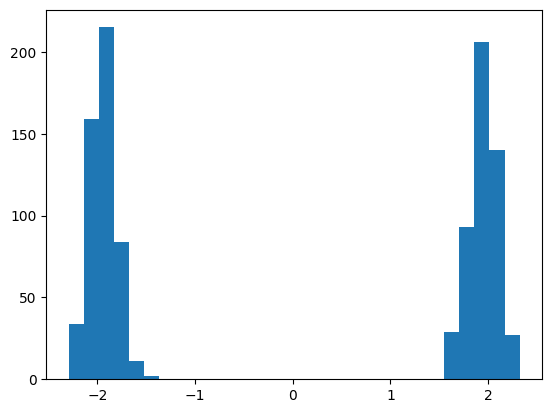

In [11]:
plt.hist(smc_samples[-1], bins=30)

In [12]:
def logdensity_fn(x, y, Sigma):
    """
    Log-pdf of ``(x, y) ~ MvNormal(0, Sigma)``.
    """
    z = jnp.concatenate([x, y])
    return jax.scipy.stats.multivariate_normal.logpdf(
        x=z,
        mean=jnp.zeros_like(z),
        cov=Sigma
    )

# Specific example with x.shape == y.shape == (2,)
Sigma = jnp.array([
    [1., 0., .8, 0.],
    [0., 1., 0., .8],
    [.8, 0., 1., 0.],
    [0., .8, 0., 1.]
])

def logdensity(x, y):
    return logdensity_fn(x, y, Sigma=Sigma)

In [13]:
# MCMC initializers for each set of paramters
mwg_init_x = blackjax.rmh.init
mwg_init_y = blackjax.hmc.init

# MCMC updaters
mwg_step_fn_x = blackjax.rmh.build_kernel()
mwg_step_fn_y = blackjax.hmc.build_kernel()  # default integrator, etc.

In [14]:
parameters = {
    "x": {
        "transition_generator": blackjax.mcmc.random_walk.normal(.2 * jnp.eye(2))
    },
    "y": {
        "inverse_mass_matrix": jnp.array([1., 1.]),
        "num_integration_steps": 100,
        "step_size": 1e-2
    }
}

initial_state = {
    "x": mwg_init_x(
        position=jnp.array([0., 0.]),
        logdensity_fn=lambda x: logdensity(x=x, y=jnp.array([0., 0.]))
    ),
    "y": mwg_init_y(
        position=jnp.array([0., 0.]),
        logdensity_fn=lambda y: logdensity(y=y, x=jnp.array([0., 0.]))
    )
}

init_fn = {
    "x": partial(mwg_init_x, position=jnp.array([0., 0.])),
    "y": partial(mwg_init_y, position=jnp.array([0., 0.]))
}

step_fn = {
    "x": partial(mwg_step_fn_x),
    "y": partial(mwg_step_fn_y)
}


In [15]:
def mwg_kernel_general(rng_key, state, logdensity_fn, step_fn, init, parameters):
    rng_keys = jax.random.split(rng_key, num=len(state))
    rng_keys = dict(zip(state.keys(), rng_keys))

    # avoid modifying argument state as JAX functions should be pure
    state = state.copy()

    for k in state.keys():
        # logdensity of component k conditioned on all other components in state
        def logdensity_k(value):
            kwargs = {_k: state[_k].position for _k in state.keys()}
            kwargs[k] = value
            return logdensity_fn(**kwargs)

        # give state[k] the right log_density
        state[k] = init[k](
            position=state[k].position,
            logdensity_fn=logdensity_k
        )

        # update state[k]
        state[k], _ = step_fn[k](
            rng_key=rng_keys[k],
            state=state[k],
            logdensity_fn=logdensity_k,
            **parameters[k]
        )

    return state

mwg_kernel = partial(mwg_kernel_general, logdensity_fn=logdensity, step_fn=step_fn, init=init_fn, parameters=parameters)

In [ ]:
mwg_kernel(rng_key, initial_state)

In [16]:

def sampling_loop(rng_key, initial_state, parameters, num_samples):

    def one_step(state, rng_key):
        state = mwg_kernel(
            rng_key=rng_key,
            state=state,
            parameters=parameters
        )
        positions = {k: state[k].position for k in state.keys()}
        return state, positions

    keys = jax.random.split(rng_key, num_samples)
    _, positions = jax.lax.scan(one_step, initial_state, keys)

    return positions

In [17]:
rng_key, sample_key = jax.random.split(rng_key)

In [18]:
positions = sampling_loop(sample_key, initial_state, parameters, 1)